# 4. Nyx on real data - humans (five stages)

The human pipeline, start to end. Same code as the rodent one in
`03_score_rodents.ipynb` — what differs is how many clustering steps run and what
the clusters are called.

Human recordings are short and quiet, and lying still awake looks like sleep to
an EMG. So wake is **not** taken from EMG power here. The EMG threshold is set
deliberately permissive so that every epoch starts as SLEEP, and wake is
recovered from the EEG by the first clustering step.

Four steps, each subdividing what the last one left:

| step | takes | produces |
|---|---|---|
| EMG threshold | — | everything → SLEEP |
| 1. wake / sleep | SLEEP | WAKE / SLEEP |
| 2. split wake | WAKE | WAKE / NREM1 |
| 3. split sleep | SLEEP | NREM2 / NREM3 / REM |

Collapsing the result gives the 4- and 3-stage versions for free.

> ### STOP
> what to look at, and what to change if it is wrong

## 1. Imports and setup

In [1]:
import os

for _var in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS",
             "NUMEXPR_NUM_THREADS", "BLIS_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_var] = "1"

import matplotlib.pyplot as plt
import pandas as pd

import nyx
from nyx.steps import Refinement, Step, run_step

## 2. Configuration

Point this at a human PSG recording. nyx has a recipe for the Dreem Open
Datasets, which know the folder layout and the scoring format:

```python
from nyx.datasets import list_datasets, load_dataset

recording, reference = load_dataset("dodh", data_root=DATA_ROOT,
                                    recording_name=RECORDING)
```

Any human PSG works — the recipe is a convenience, not a requirement. Loading a
file directly is the cell below.

`nyx.datasets.list_datasets()` shows the recipes that exist (dodh, dodo, SIESTA,
MESA, CHAT, CCSHS, ANPHY-Sleep).

In [2]:
RECORDING_PATH = r"...\recording.edf"      # <- your file
SCORING_PATH = r"...\scoring.csv"          # <- or None if you have none
OUTPUT_DIR = "../results/human01"

# Human montages name their channels, and the names are not consistent between
# datasets. Read describe() below and correct these before going on.
EEG_CHANNEL = "C3_M2"
EMG_CHANNEL = "EMG"

params = nyx.load_params("human")

## 3. Load the recording and the manual scoring

In [3]:
recording = nyx.read_recording(RECORDING_PATH,
                               eeg_channel=EEG_CHANNEL,
                               emg_channel=EMG_CHANNEL,
                               name=os.path.basename(RECORDING_PATH))
print(recording.describe())

reference = None
if SCORING_PATH:
    # 30 s epochs is the human standard. label_map translates whatever coding
    # the file uses; leave it out if it already holds stage names.
    reference = nyx.read_annotations(
        SCORING_PATH, format="epoch_csv", epoch_length=30,
        label_map={0: "WAKE", 1: "NREM1", 2: "NREM2", 3: "NREM3", 4: "REM"},
    )
    totals = {}
    for duration, label in zip(reference["duration"], reference["label"]):
        totals[str(label)] = totals.get(str(label), 0.0) + float(duration)
    total = sum(totals.values())
    print("\nmanual scoring:")
    for label, seconds in sorted(totals.items()):
        print(f"  {label:<10} {seconds / 3600:5.2f} h  ({100 * seconds / total:.1f}%)")

FileNotFoundError: Recording not found: ...\recording.edf

In [3]:
from nyx.datasets import list_datasets, load_dataset

recording, reference = load_dataset("dodh", data_root="F:\\NCMM_sleep\\data",
                                    recording_name="0d79f4b1-e74f-5e87-8e42-f9dd7112ada5")
print(recording.describe())
totals = {}
for duration, label in zip(reference["duration"], reference["label"]):
    totals[str(label)] = totals.get(str(label), 0.0) + float(duration)
total = sum(totals.values())
print("\nmanual scoring:")
for label, seconds in sorted(totals.items()):
    print(f"  {label:<10} {seconds / 3600:5.2f} h  ({100 * seconds / total:.1f}%)")

c:\Users\letizias\.conda\envs\nyx_dev\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0d79f4b1-e74f-5e87-8e42-f9dd7112ada5: 29040.0s at 250 Hz
  EEG channel: C3_M2
  EMG channel: EMG

manual scoring:
  NOSIGNAL    0.03 h  (0.3%)
  NREM1       0.56 h  (6.9%)
  NREM2       3.01 h  (37.3%)
  NREM3       1.37 h  (16.9%)
  REM         1.57 h  (19.5%)
  WAKE        1.53 h  (19.0%)


> ### STOP — check channels
>
> Check the two names printed above. Picking the wrong channel is the most
> common mistake.
>
> A manual scoring is **optional** — nyx never uses it to produce anything. It
> is only read at the end, to measure agreement.

## 3b. Signal check

Traces and spectrograms for the start and end of the recording, plus a
measurement of mains interference.

0d79f4b1-e74f-5e87-8e42-f9dd7112ada5: 29040s at 250 Hz
  previewed: start 0-10000s, end 19040-29040s
  line-noise check (peak above local baseline):
    EEG_50Hz         -0.6 dB
    EEG_60Hz         -0.3 dB
    EMG_50Hz        +12.0 dB  <- consider a notch
    EMG_60Hz         +0.2 dB
  suggestion: set "notch": 50 in the EEG/EMG params.


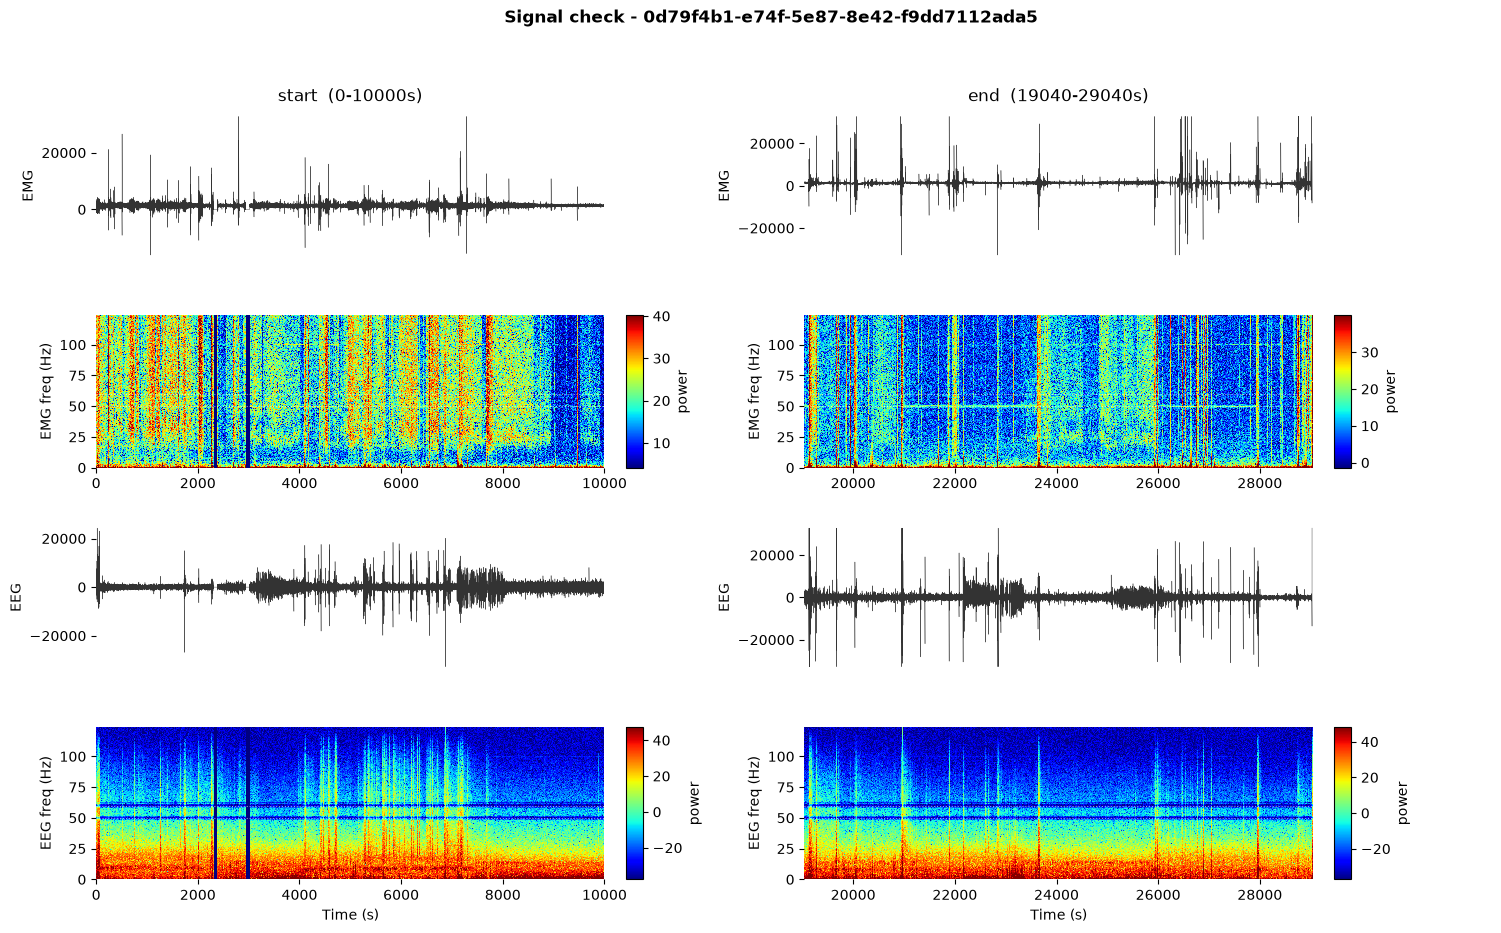

In [4]:
check = nyx.check_signals(recording)
print(check.summary())
check.plot()
plt.show()

> ### STOP — mains, and where to start and stop
>
> Line-noise scores above 3 dB are worth notching, and you should be able to see
> the line in the spectrograms. Clinical PSG is often already filtered, in which
> case there is nothing to do.
>
> Look for flat or saturated stretches at either end — electrodes going on and
> coming off — and set `WINDOW` inside them.

## 4. Trim the signal

In [5]:
# A notch goes in the params, so it is recorded in run.json and replays.
NOTCH = check.suggested_notch()      # None, 50 or 60

# params["EEG"]["notch"] = NOTCH
params["EMG"]["notch"] = NOTCH
print("notch:", NOTCH)

# None = the whole recording, otherwise (start, end) in seconds.
WINDOW = None

notch: 50.0


In [6]:
processed = nyx.preprocess_recording(recording, params)
windowed = processed if WINDOW is None else processed.time_slice(*WINDOW)
window = (0.0, processed.duration) if WINDOW is None else WINDOW
print(f"analysing {window[0]:g}-{window[1]:g}s of {processed.duration:.0f}s")

analysing 0-29040s of 29040s


c:\Users\letizias\.conda\envs\nyx_dev\Lib\site-packages\spikeinterface\preprocessing\filter.py:122: UserWarning: The margin size (238 samples) is more than 20% of the global chunk size 250 samples. This may lead to performance bottlenecks when chunking. Consider increasing the chunk_size or chunk_duration to minimize margin overhead.
  warnings.warn(
c:\Users\letizias\.conda\envs\nyx_dev\Lib\site-packages\spikeinterface\preprocessing\filter.py:122: UserWarning: The margin size (119 samples) is more than 20% of the global chunk size 250 samples. This may lead to performance bottlenecks when chunking. Consider increasing the chunk_size or chunk_duration to minimize margin overhead.
  warnings.warn(


## 5. EMG — everything starts as SLEEP

This is where the human pipeline diverges from the rodent one. In a rodent, EMG
power separates wake from sleep and the threshold does the work. In a human,
lying still awake looks exactly like sleep to an EMG, so a threshold on it would
call quiet wake asleep.

Instead the threshold is set **above the top of the range**, so nothing is
called wake on EMG power alone and every epoch starts as SLEEP. Wake is
recovered from the EEG by step 1.

The EMG is still computed and still used — as an extra clustering *feature* in
step 1, where it helps separate wake without having to decide a cut.

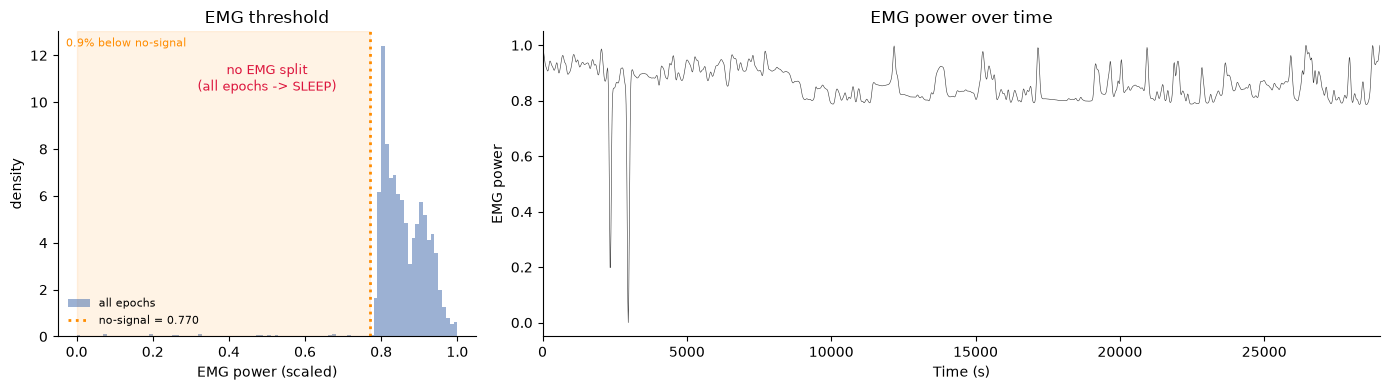

after the EMG step: {np.str_('NOSIGNAL'): np.int64(2), np.str_('SLEEP'): np.int64(3)}


In [7]:
emg = nyx.compute_emg_features(windowed, params)

# 1.1 is above the maximum of the min-max scaled power, so nothing is WAKE.
NOSIGNAL_THRESHOLD = 0.77
EMG_THRESHOLD = 1.1

nyx.plot_emg_check(emg, threshold=EMG_THRESHOLD, nosignal=NOSIGNAL_THRESHOLD)
plt.show()

wake_sleep = nyx.classify_wake_sleep(
    emg, threshold=EMG_THRESHOLD, nosignal_threshold=NOSIGNAL_THRESHOLD,
    min_duration=params.get("scoring", {}).get("min_duration", 4.0),
)
print("after the EMG step:", dict(
    zip(*__import__("numpy").unique(wake_sleep.hypnogram["label"], return_counts=True))
))

> ### STOP — is everything SLEEP?
>
> It should be. The histogram is drawn so you can see the threshold sitting
> above the whole distribution, and the label count below it should show SLEEP
> and nothing else.
>
> **If your EMG does separate cleanly** — some research-grade recordings do —
> you can use it: set `EMG_THRESHOLD = None` for the automatic cut, and skip
> step 1 below.

## 6. Step 1 — wake / sleep from the EEG

The first clustering step. PCA is fitted on the epochs currently labelled
SLEEP — which is all of them — and clustered with the EMG as an extra feature.

`elliptic` rather than k-means: it fits a robust Gaussian to the bulk of the
data and calls the tail outliers. Sleep is one dense blob and wake is the
scattered minority, so a method that models "the bulk plus everything else"
suits that better than one assuming two comparable clusters.

`elliptic_contamination` is how much of the recording is treated as that tail —
**the main thing to tune here.** 0.1 suits a night with about 10% wake; a
restless night or one with a long settling period needs more.

In [8]:
step1 = Step(
    name="wake_sleep",
    within="SLEEP",
    method="gmm",
    pcs_to_use=[0, 1],
    use_emg=True,
    # stage_order=["SLEEP", "WAKE"],     # elliptic: [the bulk, the tail]
    options={"elliptic_contamination": 0.1,
             "elliptic_support_fraction": 0.75},
)

out1 = run_step(windowed, params, wake_sleep.hypnogram, step1, emg=emg)
print(out1.summary())

step 'wake_sleep': split 'SLEEP' with gmm
    C0 -> SLEEP_C0    1354 epochs (70.6%)
    C1 -> SLEEP_C1     564 epochs (29.4%)


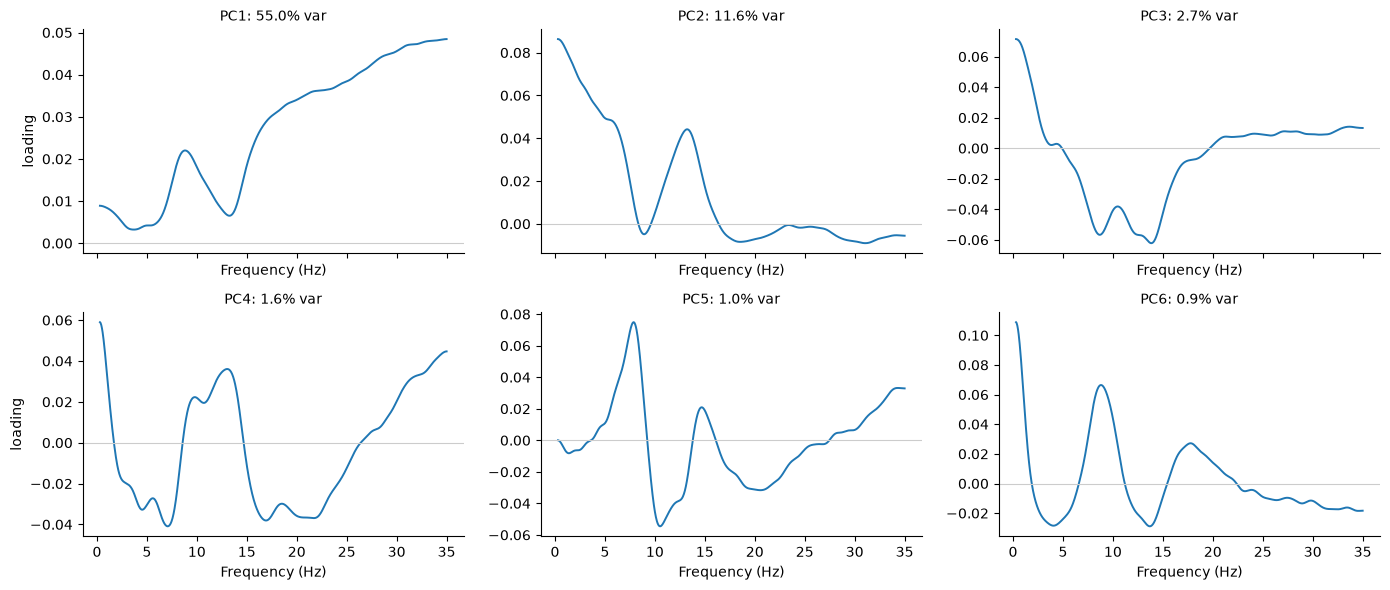

In [9]:
nyx.plot_pca_grid(out1.pca, smooth=15)
plt.show()

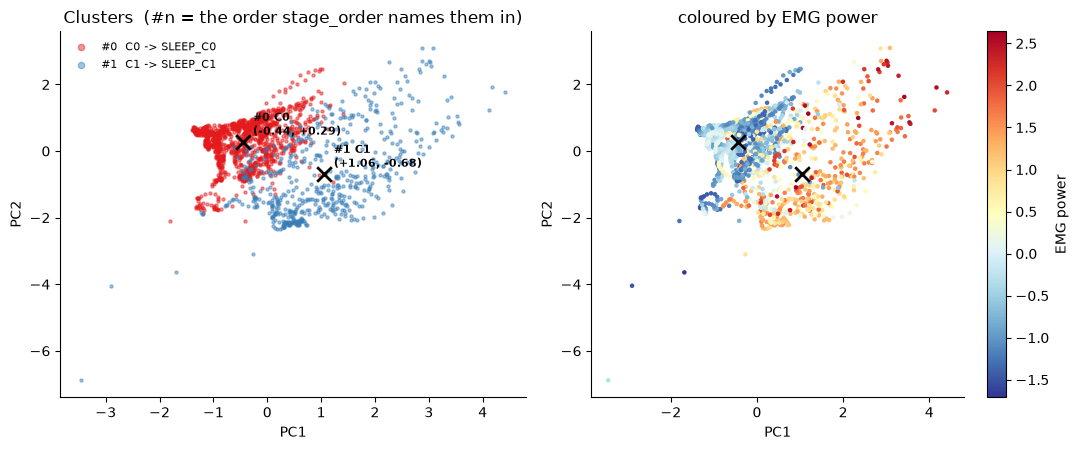

In [10]:
nyx.plot_cluster_features(out1.clusters, stages=out1.cluster_to_stage)
plt.show()

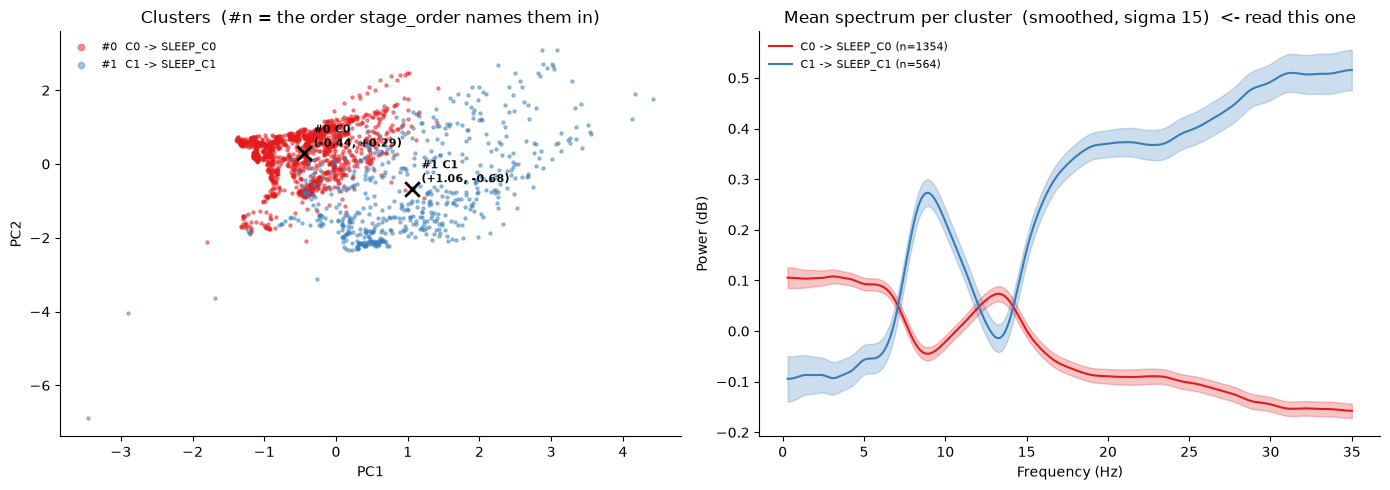

,cluster,PC1,PC2,EMG,epochs,stage
order,,,,,,
0,0,-0.4444,0.2858,-0.4927,1354,SLEEP_C0
1,1,1.0568,-0.6798,1.1718,564,SLEEP_C1


In [11]:
nyx.plot_cluster_check(out1.pca, clusters=out1.clusters,
                       stages=out1.cluster_to_stage, smooth=15)
plt.show()

nyx.cluster_ordering(out1.clusters, out1.cluster_to_stage)

In [12]:
# Name the clusters.
#
STAGE_ORDER = ["SLEEP", "WAKE"]   # by position in the `order` column above
OVERRIDES = None                  # or by cluster id, e.g. {0: "WAKE", 1: "SLEEP"}

out1 = nyx.rename_clusters(out1, stage_order=STAGE_ORDER,
                           cluster_to_stage=OVERRIDES)
print(out1.summary())

step 'wake_sleep': split 'SLEEP' with gmm
    C0 -> SLEEP       1354 epochs (70.6%)
    C1 -> WAKE         564 epochs (29.4%)


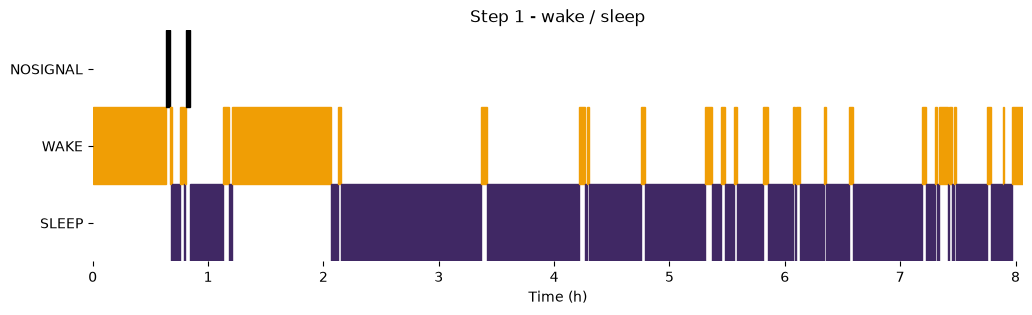

In [13]:
nyx.plot_hypnogram_result(out1.hypnogram, title="Step 1 - wake / sleep")
plt.show()

> ### STOP — how much wake did that find?
>
> Compare against the manual scoring printed in section 3, if you have one, and
> against what you know about the night. Too little wake means raising
> `elliptic_contamination`; too much means lowering it.
>
> Unlike the other steps, `elliptic` orders its clusters as **[the bulk, the
> tail]** rather than by centroid — so `stage_order` here is
> `["SLEEP", "WAKE"]` and does not depend on which side of PC1 the tail landed.
>
> Everything after this only subdivides what step 1 produced, so wake that is
> wrong here stays wrong. Do not go on until it looks right.

## 7. Step 2 — split wake into WAKE and NREM1

N1 is light, drowsy sleep, and it sits spectrally between wake and N2 — which
is why it is the stage human scorers agree on least. Here it is separated out
of what step 1 called wake.

Mapping **both** clusters to `WAKE` makes this step a no-op, which is the
natural way to decide, after looking at it, that the split was not worth
keeping. Several of the archived runs did exactly that.

In [14]:
step2 = Step(
    name="split_wake",
    within="WAKE",
    method="kmeans",
    n_clusters=2,
    pcs_to_use=[0, 1, 2],
    use_emg=False,
)

out2 = run_step(windowed, params, out1.hypnogram, step2, emg=emg)
print(out2.summary())

step 'split_wake': split 'WAKE' with kmeans
    C0 -> WAKE_C0      232 epochs (41.1%)
    C1 -> WAKE_C1      332 epochs (58.9%)


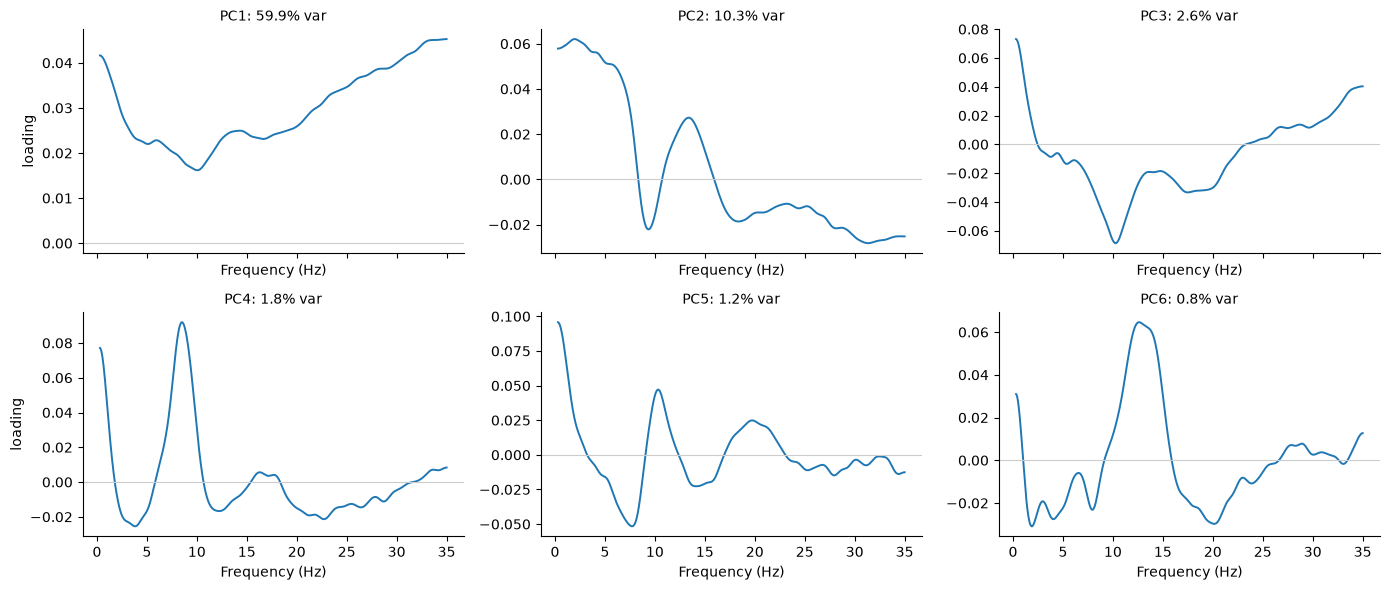

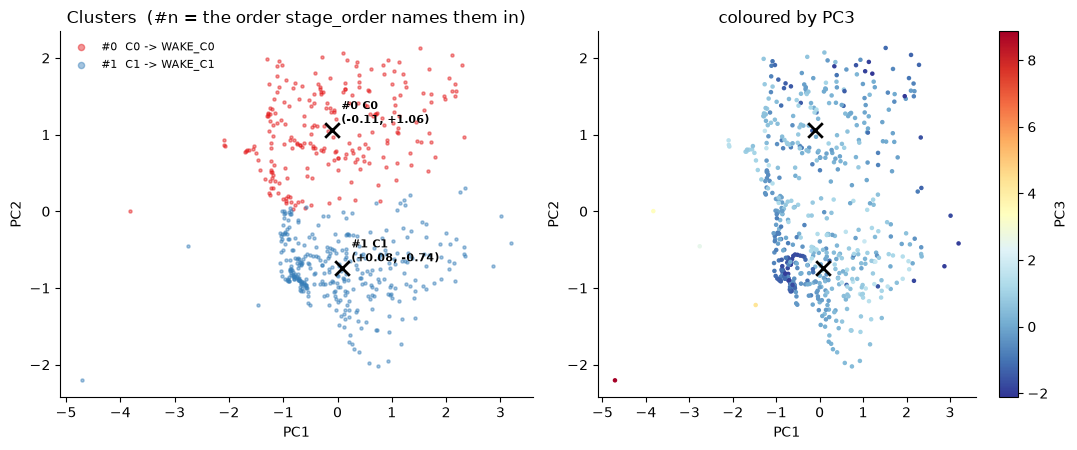

In [15]:
nyx.plot_pca_grid(out2.pca, smooth=15)
nyx.plot_cluster_features(out2.clusters, stages=out2.cluster_to_stage)
plt.show()

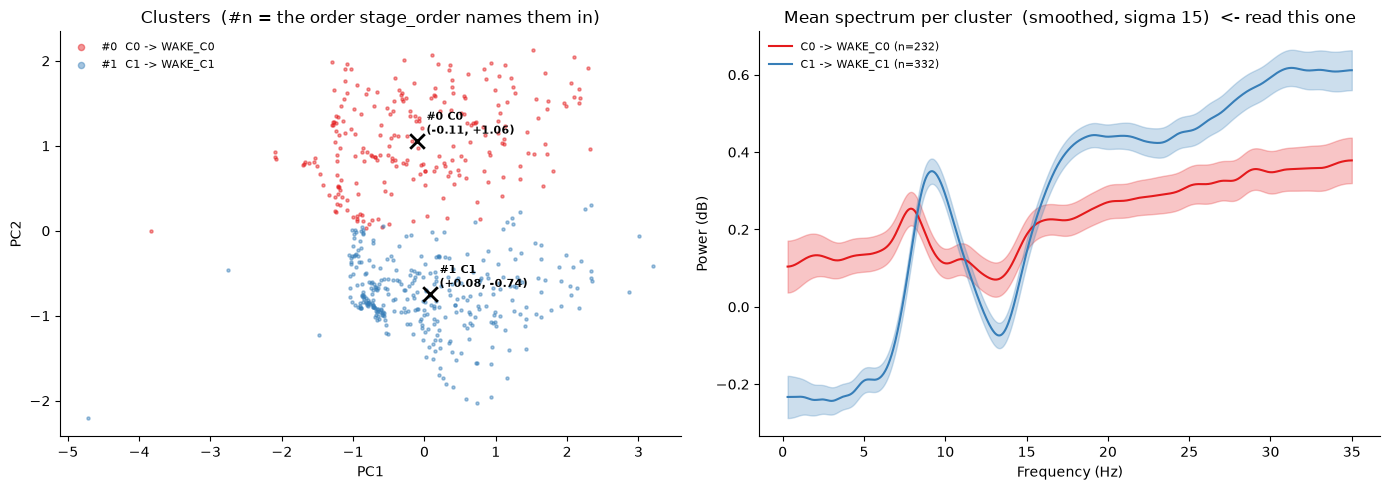

,cluster,PC1,PC2,PC3,epochs,stage
order,,,,,,
0,0,-0.1084,1.0615,0.1150,232,WAKE_C0
1,1,0.0757,-0.7418,-0.0804,332,WAKE_C1


In [16]:
nyx.plot_cluster_check(out2.pca, clusters=out2.clusters,
                       stages=out2.cluster_to_stage, smooth=15)
plt.show()

nyx.cluster_ordering(out2.clusters, out2.cluster_to_stage)

> ### STOP — is the N1 cluster really N1?
>
> N1 should show **less** alpha than wake and a little more theta. If the two
> spectra are near-identical, the split is not finding anything: set
> `stage_order=["WAKE", "WAKE"]` and move on.

step 'split_wake': split 'WAKE' with kmeans
    C0 -> NREM1        232 epochs (41.1%)
    C1 -> WAKE         332 epochs (58.9%)


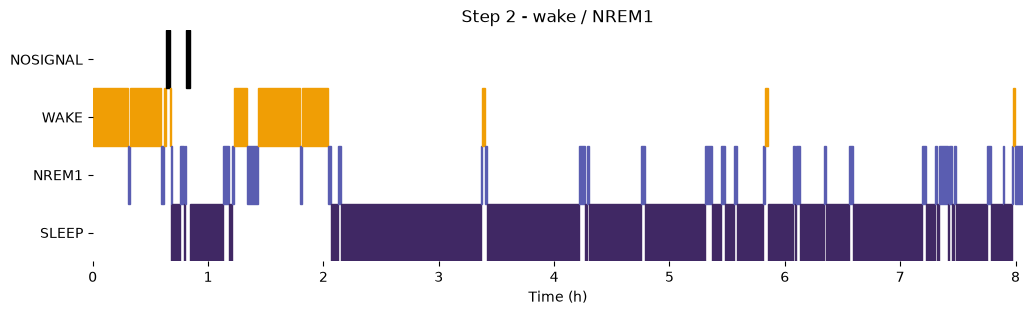

In [17]:
# Name the clusters.
#
# Mapping BOTH clusters to "WAKE" makes this step a no-op, which is how you
# decide, having looked at it, that the N1 split was not worth keeping.
STAGE_ORDER = ["NREM1", "WAKE"]   # by position in the `order` column above
OVERRIDES = None                  # or by cluster id

out2 = nyx.rename_clusters(out2, stage_order=STAGE_ORDER,
                           cluster_to_stage=OVERRIDES)
print(out2.summary())

nyx.plot_hypnogram_result(out2.hypnogram, title="Step 2 - wake / NREM1")
plt.show()

## 8. Step 3 — split sleep into NREM2, NREM3 and REM

Four clusters for three stages, because N2 is heterogeneous — spindles and
K-complexes give it more than one spectral signature — so two of the four are
normally mapped to NREM2.

In [18]:
step3 = Step(
    name="split_sleep",
    within="SLEEP",
    method="gmm",
    n_clusters=4,
    pcs_to_use=[0, 1, 2],
    use_emg=False,
)

out3 = run_step(windowed, params, out2.hypnogram, step3, emg=emg)
print(out3.summary())

step 'split_sleep': split 'SLEEP' with gmm
    C0 -> SLEEP_C0     235 epochs (17.4%)
    C1 -> SLEEP_C1     387 epochs (28.6%)
    C2 -> SLEEP_C2     369 epochs (27.3%)
    C3 -> SLEEP_C3     363 epochs (26.8%)


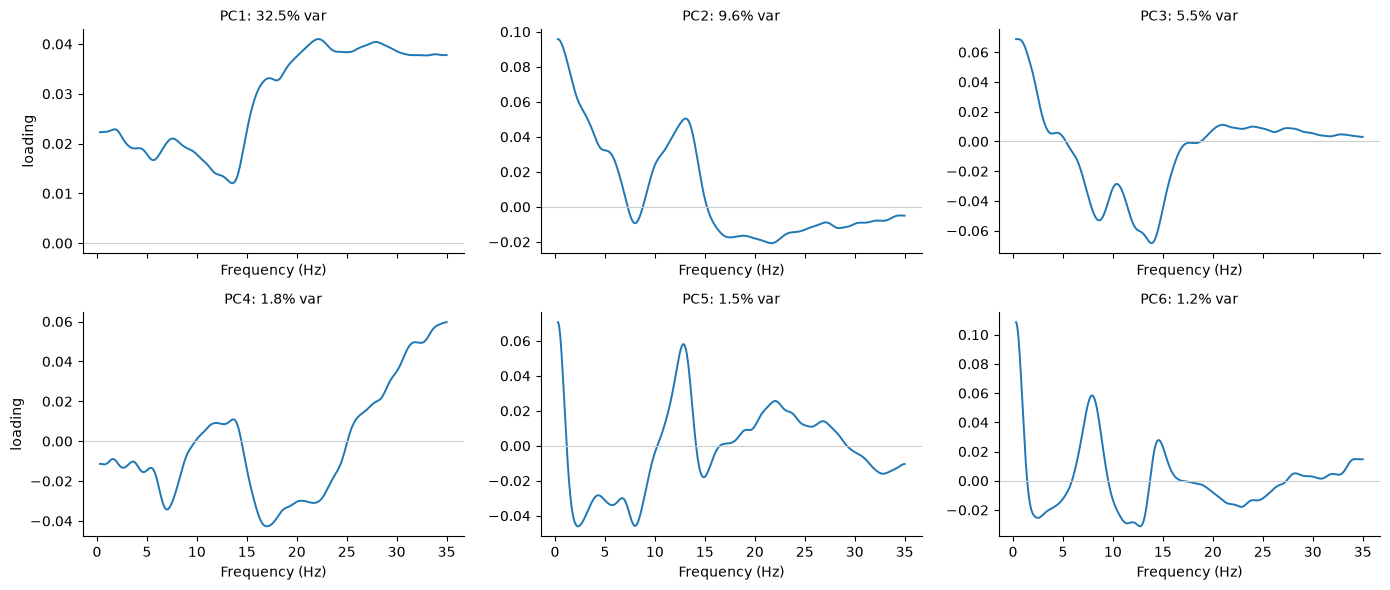

In [19]:
nyx.plot_pca_grid(out3.pca, smooth=15)
plt.show()

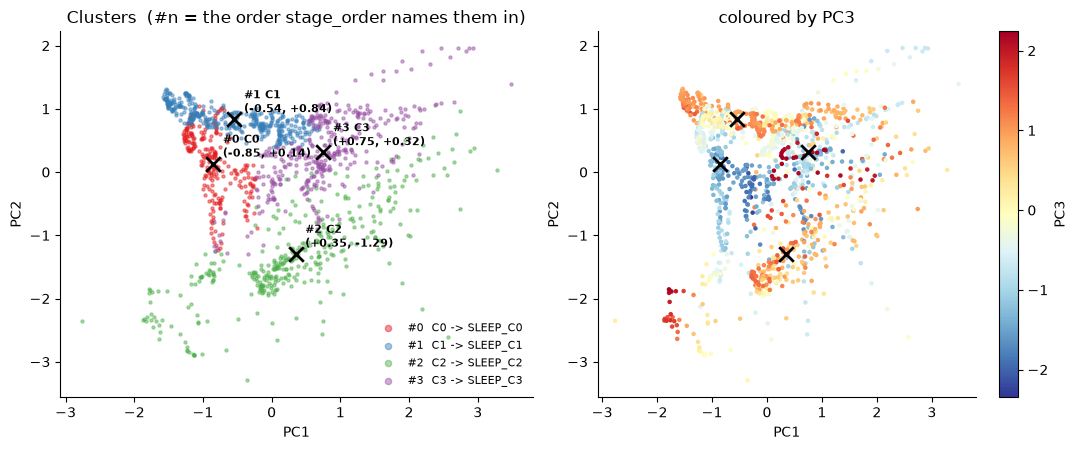

In [20]:

nyx.plot_cluster_features(out3.clusters, stages=out3.cluster_to_stage)
plt.show()

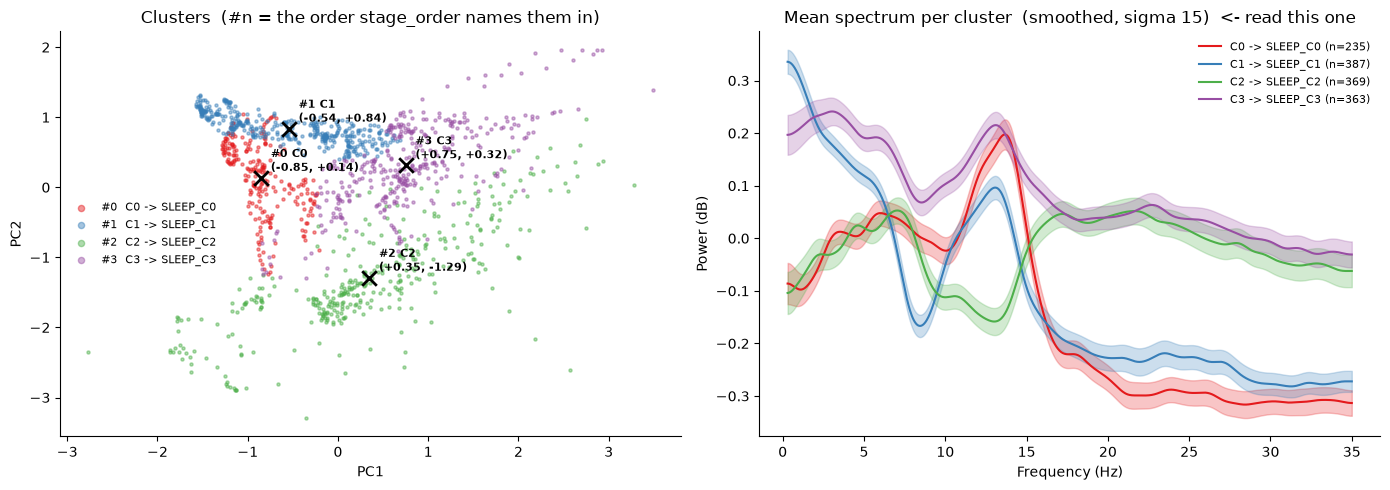

,cluster,PC1,PC2,PC3,epochs,stage
order,,,,,,
0,0,-0.8514,0.1354,-1.0818,235,SLEEP_C0
1,1,-0.5430,0.8384,0.4565,387,SLEEP_C1
2,2,0.3476,-1.2893,0.5507,369,SLEEP_C2
3,3,0.7515,0.3164,-0.3563,363,SLEEP_C3


In [21]:
nyx.plot_cluster_check(out3.pca, clusters=out3.clusters,
                       stages=out3.cluster_to_stage, smooth=15)
plt.show()


nyx.cluster_ordering(out3.clusters, out3.cluster_to_stage)

> ### STOP — which cluster is which stage?
>
> **This is the step most worth getting right.** Read the spectra:
>
> - **NREM3** — the most delta (0.5–4 Hz) by a clear margin.
> - **NREM2** — less delta, often a bump around 12–15 Hz from spindles.
> - **REM** — least delta, relatively flat, theta-ish.
>
> Then set `stage_order` to match, by **position** in the `order` column. If two
> clusters look like the same stage, map both to it — that is what the repeated
> `NREM2` above is doing.
>
> To name clusters by id instead of by position, pass
> `cluster_to_stage={0: "NREM2", 1: "REM", 2: "NREM3", 3: "NREM2"}` to the
> `Step`. Cluster ids are renumbered by centroid, so a saved mapping means the
> same thing on every run.

step 'split_sleep': split 'SLEEP' with gmm
    C0 -> NREM2        235 epochs (17.4%)
    C1 -> NREM3        387 epochs (28.6%)
    C2 -> REM          369 epochs (27.3%)
    C3 -> NREM2        363 epochs (26.8%)


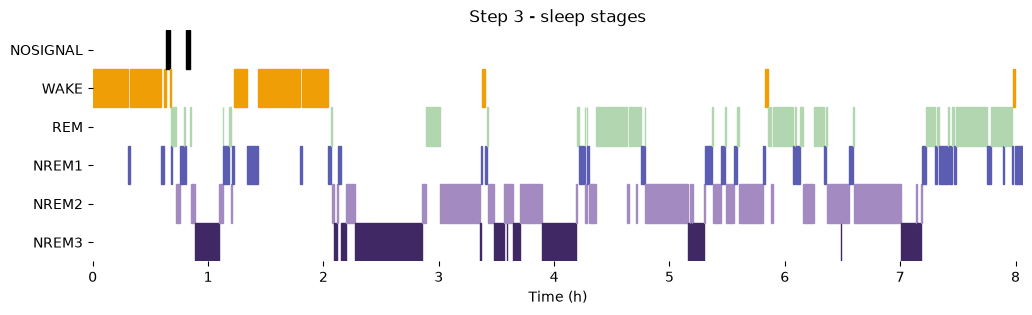

In [22]:
# Name the clusters. Instant -- no re-clustering.
#
# Four clusters, three stages: two of them normally map to NREM2, which is
# heterogeneous. Read the spectra above, not the cluster ids.
STAGE_ORDER = ["NREM2", "NREM3", "REM", "NREM2"]   # by position
OVERRIDES = None                                   # or by cluster id

out3 = nyx.rename_clusters(out3, stage_order=STAGE_ORDER,
                           cluster_to_stage=OVERRIDES)
print(out3.summary())

nyx.plot_hypnogram_result(out3.hypnogram, title="Step 3 - sleep stages")
plt.show()

## 8b. Refining a stage by a component (optional)

Where a clustering leaves two stages merged that a single component does
separate — N1 out of N2, typically. The refinement thresholds one PC *within*
one output stage, after the clusters have been named.

Off by default. Turn it on only when the spectra above show a stage that is
clearly two things.

In [23]:
ENABLE_REFINEMENT = False

if ENABLE_REFINEMENT:
    # Also instant -- the refinement thresholds a component within an already
    # named stage, so nothing is re-clustered.
    out3 = nyx.rename_clusters(
        out3,
        refinements=[Refinement(split_stage="NREM2", pc=1, threshold=1.19,
                                high="NREM2", low="NREM1")],
    )
    print(out3.summary())

## 9. Final scoring — 5, 4 and 3 stages

Scoring ran once, at the finest granularity it can reach. The coarser versions
are merges of that one, so they are guaranteed consistent with each other rather
than three separate scorings that might disagree.

- **4-stage** folds N1 into N2 — the pair scorers separate least reliably, and
  N1 is a small fraction of the night.
- **3-stage** merges all NREM, which is the vocabulary rodent scoring uses.

In [24]:
from nyx.granularity import available_granularities

hypnogram = out3.hypnogram
print("granularities available:", available_granularities(hypnogram))

for n in available_granularities(hypnogram):
    collapsed = nyx.collapse(hypnogram, n)
    totals = {}
    for duration, label in zip(collapsed["duration"], collapsed["label"]):
        totals[str(label)] = totals.get(str(label), 0.0) + float(duration)
    total = sum(totals.values())
    print(f"\n{n}-stage:")
    for label, seconds in sorted(totals.items()):
        print(f"  {label:<10} {seconds / 3600:5.2f} h  ({100 * seconds / total:.1f}%)")

granularities available: [5, 4, 3]

5-stage:
  NOSIGNAL    0.07 h  (0.9%)
  NREM1       0.97 h  (12.0%)
  NREM2       2.49 h  (30.9%)
  NREM3       1.61 h  (20.0%)
  REM         1.54 h  (19.1%)
  WAKE        1.38 h  (17.2%)

4-stage:
  NOSIGNAL    0.07 h  (0.9%)
  NREM2       3.46 h  (42.9%)
  NREM3       1.61 h  (20.0%)
  REM         1.54 h  (19.1%)
  WAKE        1.38 h  (17.2%)

3-stage:
  NOSIGNAL    0.07 h  (0.9%)
  NREM        5.07 h  (62.9%)
  REM         1.54 h  (19.1%)
  WAKE        1.38 h  (17.2%)


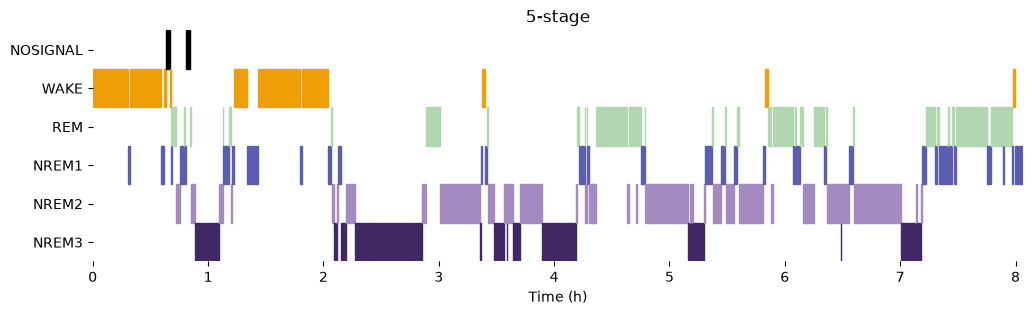

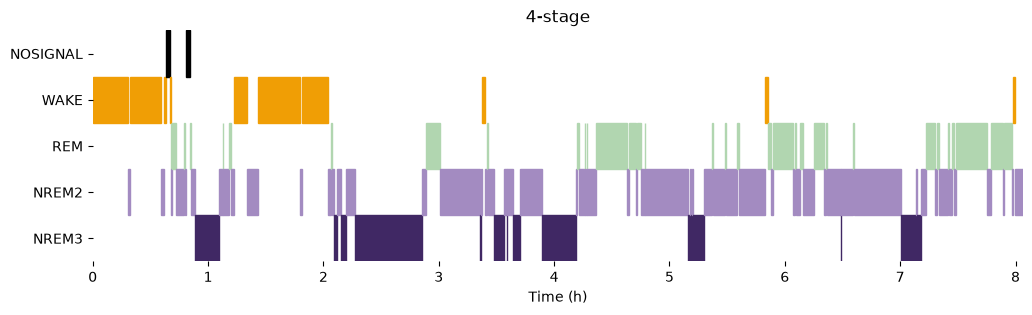

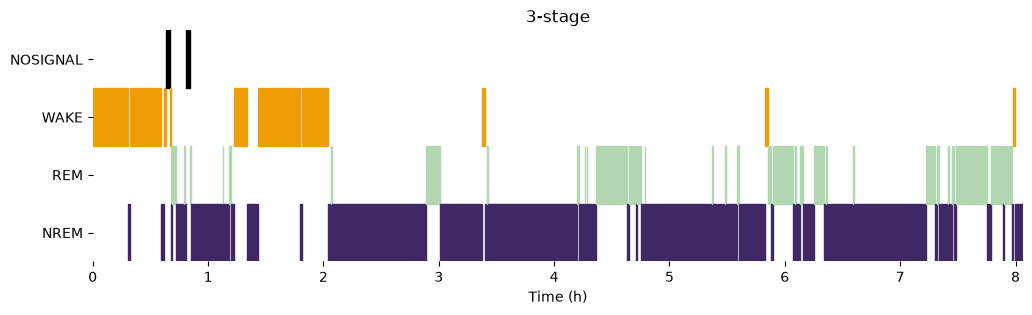

In [25]:
for n in available_granularities(hypnogram):
    nyx.plot_hypnogram_result(nyx.collapse(hypnogram, n), title=f"{n}-stage")
    plt.show()

## 10. Ground truth comparison

Optional, and only read here — nothing above used it.

Agreement is reported at each granularity. It rises as the vocabulary coarsens,
which is what you would expect: the disagreements that disappear are the N1/N2
and N2/N3 boundaries, which human scorers also disagree about. Report the
granularity that matches what you are comparing against, and say which one.

In [26]:
if reference is not None:
    for n in available_granularities(hypnogram):
        collapsed = nyx.collapse(hypnogram, n)
        stages = sorted(set(collapsed["label"].tolist()) - {"NOSIGNAL", "UNCLASSIFIED"})
        agreement = nyx.evaluate(collapsed, nyx.collapse(reference, n),
                                 window=window, label_order=stages, verbose=False)
        print(f"{n}-stage   MF1 {agreement.mf1:.3f}   "
              f"accuracy {agreement.accuracy:.3f}   kappa {agreement.kappa:.3f}")
else:
    print("No manual scoring - skipping. This is fine.")

5-stage   MF1 0.658   accuracy 0.698   kappa 0.609
4-stage   MF1 0.742   accuracy 0.730   kappa 0.618
3-stage   MF1 0.818   accuracy 0.842   kappa 0.710


In [27]:
if reference is not None:
    agreement = nyx.evaluate(hypnogram, reference, window=window, verbose=False,
                             label_order=["WAKE", "NREM1", "NREM2", "NREM3", "REM"])
    print(agreement.summary())

=== Agreement with reference scoring ===
MF1: 0.658    Accuracy: 0.698    Cohen's kappa: 0.609

      precision recall f1-score  support
WAKE      0.858  0.777    0.815  5505.0s
NREM1     0.241  0.418    0.306  2010.0s
NREM2     0.788  0.652    0.714 10830.0s
NREM3     0.641  0.756    0.694  4920.0s
REM       0.770  0.751    0.760  5670.0s

Macro average (unweighted, over stages present in the reference):
  precision 0.660   recall 0.671   MF1 0.658

Confusion matrix (rows=reference, cols=nyx, values in seconds):
         WAKE   NREM1   NREM2   NREM3     REM
WAKE   4275.0  1035.0    15.0     0.0    75.0
NREM1   600.0   840.0   165.0     0.0   390.0
NREM2    90.0   780.0  7065.0  2085.0   765.0
NREM3     0.0     0.0  1155.0  3720.0    45.0
REM      15.0   825.0   570.0     0.0  4260.0


In [28]:
import numpy as np

from nyx.pipeline import ScoringResult
from nyx.types import Staging

# A step returns its own outcome rather than a Staging, so assemble one from the
# last step. stage_signal is the WAKE/NREM/REM integer array, which a five-stage
# vocabulary does not fit -- stage_labels carries the real names.
staging = Staging(
    hypnogram=out3.hypnogram,
    cluster_to_stage=out3.cluster_to_stage,
    stage_signal=np.array([]),
    stage_labels=out3.labels,
)

result = ScoringResult(
    recording=windowed, emg=emg, wake_sleep=wake_sleep,
    pca=out3.pca, clusters=out3.clusters, staging=staging,
    agreement=(nyx.evaluate(hypnogram, reference, window=window, verbose=False,
                            label_order=["WAKE", "NREM1", "NREM2", "NREM3", "REM"])
               if reference is not None else None),
    window=window, total_duration=recording.duration, params=params,
    reference=reference, steps=[out1, out2, out3],
)


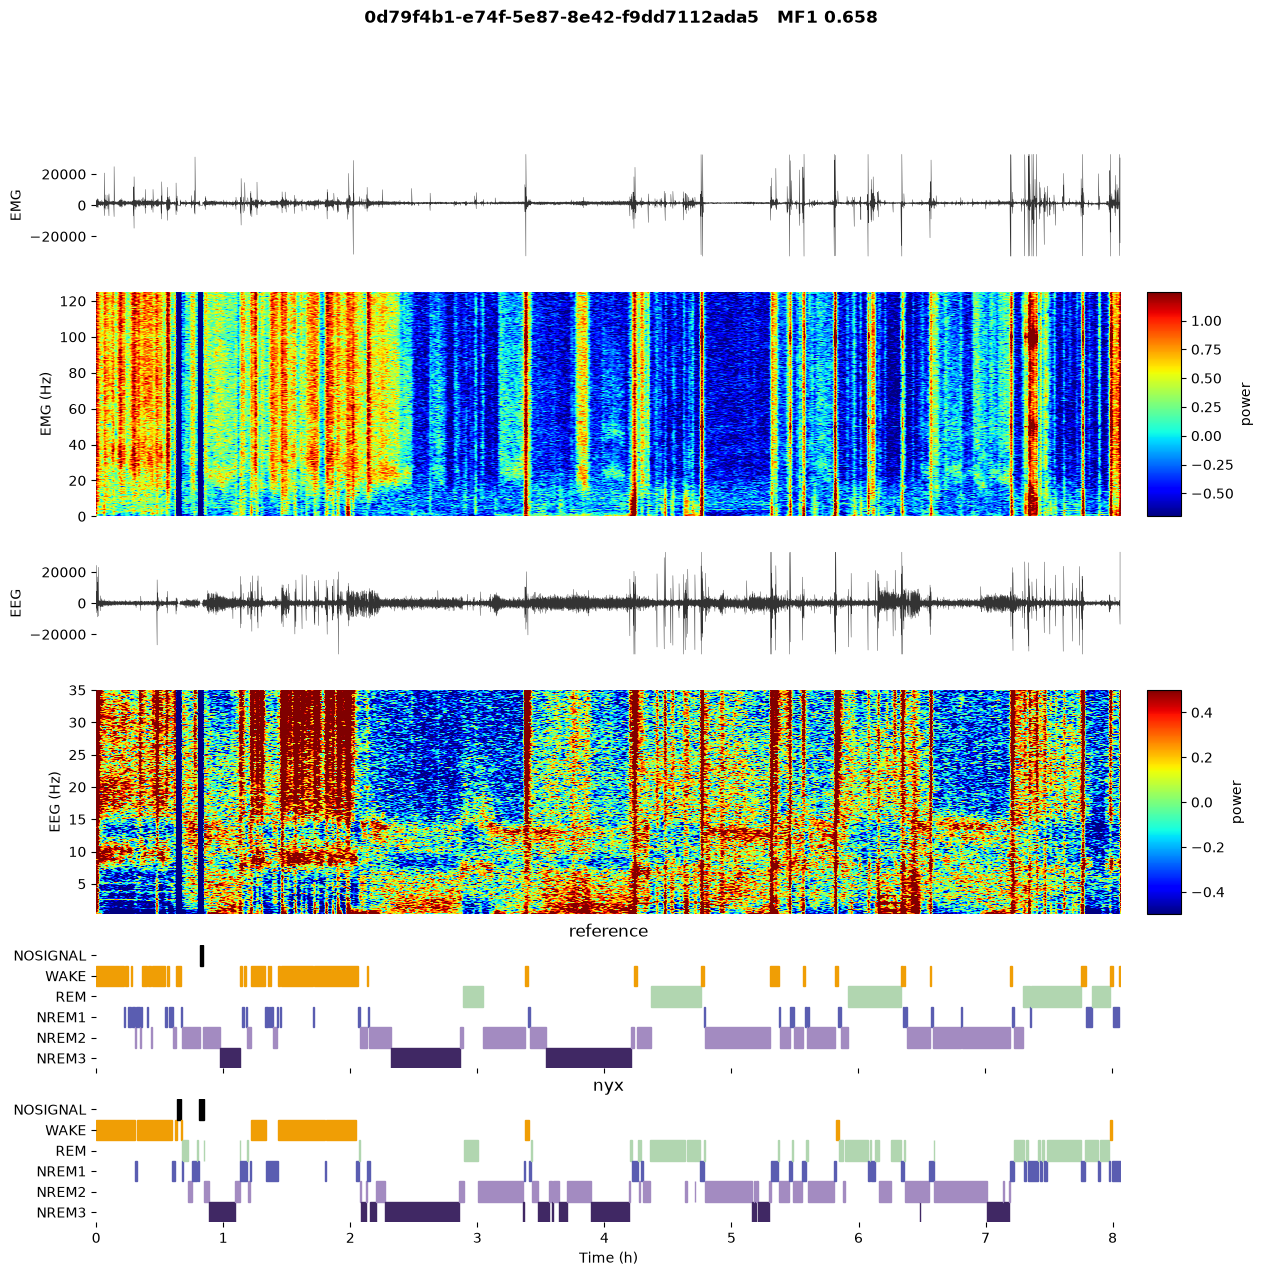

In [32]:
nyx.plot_scoring_overview(result, eeg_range=(-0.5, 0.5))
plt.show()

## 11. Save

The result is assembled from the last step, so the figures and `run.json` carry
what the whole sequence decided.

In [30]:
nyx.save_results(result, OUTPUT_DIR, granularities=[5, 4, 3])
print("saved to", os.path.abspath(OUTPUT_DIR))
print(sorted(os.listdir(OUTPUT_DIR)))

Hypnogram saved to ../results/human01\wake_sleep.csv with NOSIGNAL padding.
Hypnogram saved to ../results/human01\hypnogram.csv with NOSIGNAL padding.
Hypnogram saved to ../results/human01\hypnogram_5stage.csv with NOSIGNAL padding.
Hypnogram saved to ../results/human01\hypnogram_4stage.csv with NOSIGNAL padding.
Hypnogram saved to ../results/human01\hypnogram_3stage.csv with NOSIGNAL padding.
saved to f:\NCMM_sleep\signorelli2026\00_code\nyx\results\human01
['agreement.pkl', 'agreement.txt', 'emg_power.npy', 'hypnogram.csv', 'hypnogram_3stage.csv', 'hypnogram_4stage.csv', 'hypnogram_5stage.csv', 'plots', 'run.json', 'wake_sleep.csv']


---

## The whole thing in one call

Once a recording is set up, `human` params holds exactly the four steps
above and `score_recording` runs them:

```python
result = nyx.score_recording(recording, params, window=WINDOW,
                             reference=reference)
nyx.save_results(result, OUTPUT_DIR, granularities=[4, 3])
```

`run.json` records each step's resolved cluster-to-stage mapping — the part
that cannot be recovered from the params alone. Edit the `steps` list in your
own copy of `human.json` to keep what you worked out above.

For a whole study, put the recordings in a manifest and use `nyx.open_queue`.